<a href="https://colab.research.google.com/github/soyeonimu/Codeit_Sprint/blob/main/Mission_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

컬럼명	설명
age	나이 (숫자)
job	직업 (범주형)
marital	결혼 여부 (범주형)
education	교육 수준 (범주형)
default	신용 불량 여부 (범주형)
housing	주택 대출 여부 (범주형)
loan	개인 대출 여부 (범주형)
contact	연락 유형 (범주형)
month	마지막 연락 월 (범주형)
day_of_week	마지막 연락 요일 (범주형)
duration	마지막 연락 지속 시간, 초 단위 (숫자)
campaign	캠페인 동안 연락 횟수 (숫자)
pdays	이전 캠페인 후 지난 일수 (숫자)
previous	이전 캠페인 동안 연락 횟수 (숫자)
poutcome	이전 캠페인의 결과 (범주형)
emp.var.rate	고용 변동률 (숫자)
cons.price.idx	소비자 물가지수 (숫자)
cons.conf.idx	소비자 신뢰지수 (숫자)
euribor3m	3개월 유리보 금리 (숫자)
nr.employed	고용자 수 (숫자)
y	정기 예금 가입 여부 (이진: yes=1, no=0)

# 데이터셋 준비

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
import missingno as msno
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [92]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [93]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


# 1. EDA(탐색적 데이터 분석) - 데이터 이해

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [95]:
df.describe(include='all')

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
count,41188.00000,41188,41188,41188,41188,41188,41188,41188,41188,41188,...,41188.000000,41188.000000,41188.000000,41188,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188
unique,NaN,12,4,8,3,3,3,2,10,5,...,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN,NaN,2
top,NaN,admin.,married,university.degree,no,yes,no,cellular,may,thu,...,NaN,NaN,NaN,nonexistent,NaN,NaN,NaN,NaN,NaN,no
freq,NaN,10422,24928,12168,32588,21576,33950,26144,13769,8623,...,NaN,NaN,NaN,35563,NaN,NaN,NaN,NaN,NaN,36548
mean,40.02406,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.567593,962.475454,0.172963,NaN,0.081886,93.575664,-40.502600,3.621291,5167.035911,NaN
std,10.42125,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.770014,186.910907,0.494901,NaN,1.570960,0.578840,4.628198,1.734447,72.251528,NaN
min,17.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,0.000000,0.000000,NaN,-3.400000,92.201000,-50.800000,0.634000,4963.600000,NaN
25%,32.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.000000,999.000000,0.000000,NaN,-1.800000,93.075000,-42.700000,1.344000,5099.100000,NaN
50%,38.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,999.000000,0.000000,NaN,1.100000,93.749000,-41.800000,4.857000,5191.000000,NaN
75%,47.00000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.000000,999.000000,0.000000,NaN,1.400000,93.994000,-36.400000,4.961000,5228.100000,NaN


In [96]:
# 범주형 변수 데이터 값 종류 살펴보기
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
  print(f"{col}: {df[col].unique()}\n")

job: ['housemaid' 'services' 'admin.' 'blue-collar' 'technician' 'retired'
 'management' 'unemployed' 'self-employed' 'unknown' 'entrepreneur'
 'student']

marital: ['married' 'single' 'divorced' 'unknown']

education: ['basic.4y' 'high.school' 'basic.6y' 'basic.9y' 'professional.course'
 'unknown' 'university.degree' 'illiterate']

default: ['no' 'unknown' 'yes']

housing: ['no' 'yes' 'unknown']

loan: ['no' 'yes' 'unknown']

contact: ['telephone' 'cellular']

month: ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'mar' 'apr' 'sep']

day_of_week: ['mon' 'tue' 'wed' 'thu' 'fri']

poutcome: ['nonexistent' 'failure' 'success']

y: ['no' 'yes']



In [97]:
# 수치형 변수와 범주형 변수 구분
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns
categorical_columns = df.select_dtypes(include=['object']).columns.drop("y")

# 범주형 변수의 값 분포 확인
print('📍 Categorical_columns')
for col in categorical_columns:
    print(f"\n{df[col].value_counts()}\n{'='*30}")

# 수치형 변수의 값 분포 확인
print('📍 Numeric_columns')
for col in numeric_columns:
    print(f"\n{df[col].value_counts()}\n{'='*30}")


📍 Categorical_columns

job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

default
no         32588
unknown     8597
yes            3
Name: count, dtype: int64

housing
yes        21576
no         18622
unknown      990
Name: count, dtype: int64

loan
no         33950
yes         6248
unknown      990
Name: count, dtype: int64

contact
cellular     26144
telephone   

## 중복값

In [98]:
df[df.duplicated(keep=False)]

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
1265,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
1266,39,blue-collar,married,basic.6y,no,no,no,telephone,may,thu,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
12260,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
12261,36,retired,married,unknown,no,no,no,telephone,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.966,5228.1,no
14155,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
14234,27,technician,single,professional.course,no,no,no,cellular,jul,mon,...,2,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16819,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
16956,47,technician,divorced,high.school,no,yes,no,cellular,jul,thu,...,3,999,0,nonexistent,1.4,93.918,-42.7,4.962,5228.1,no
18464,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no
18465,32,technician,single,professional.course,no,yes,no,cellular,jul,thu,...,1,999,0,nonexistent,1.4,93.918,-42.7,4.968,5228.1,no


In [99]:
df = df.drop_duplicates()

## 결측치

In [100]:
print(df.isna().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


 - ( UNKNOWN ) 을 결측치로 보고 확인

In [101]:
# 알수없음 결측값으로 대체
df.replace('unknown',pd.NA, inplace=True)

<Figure size 1000x800 with 0 Axes>

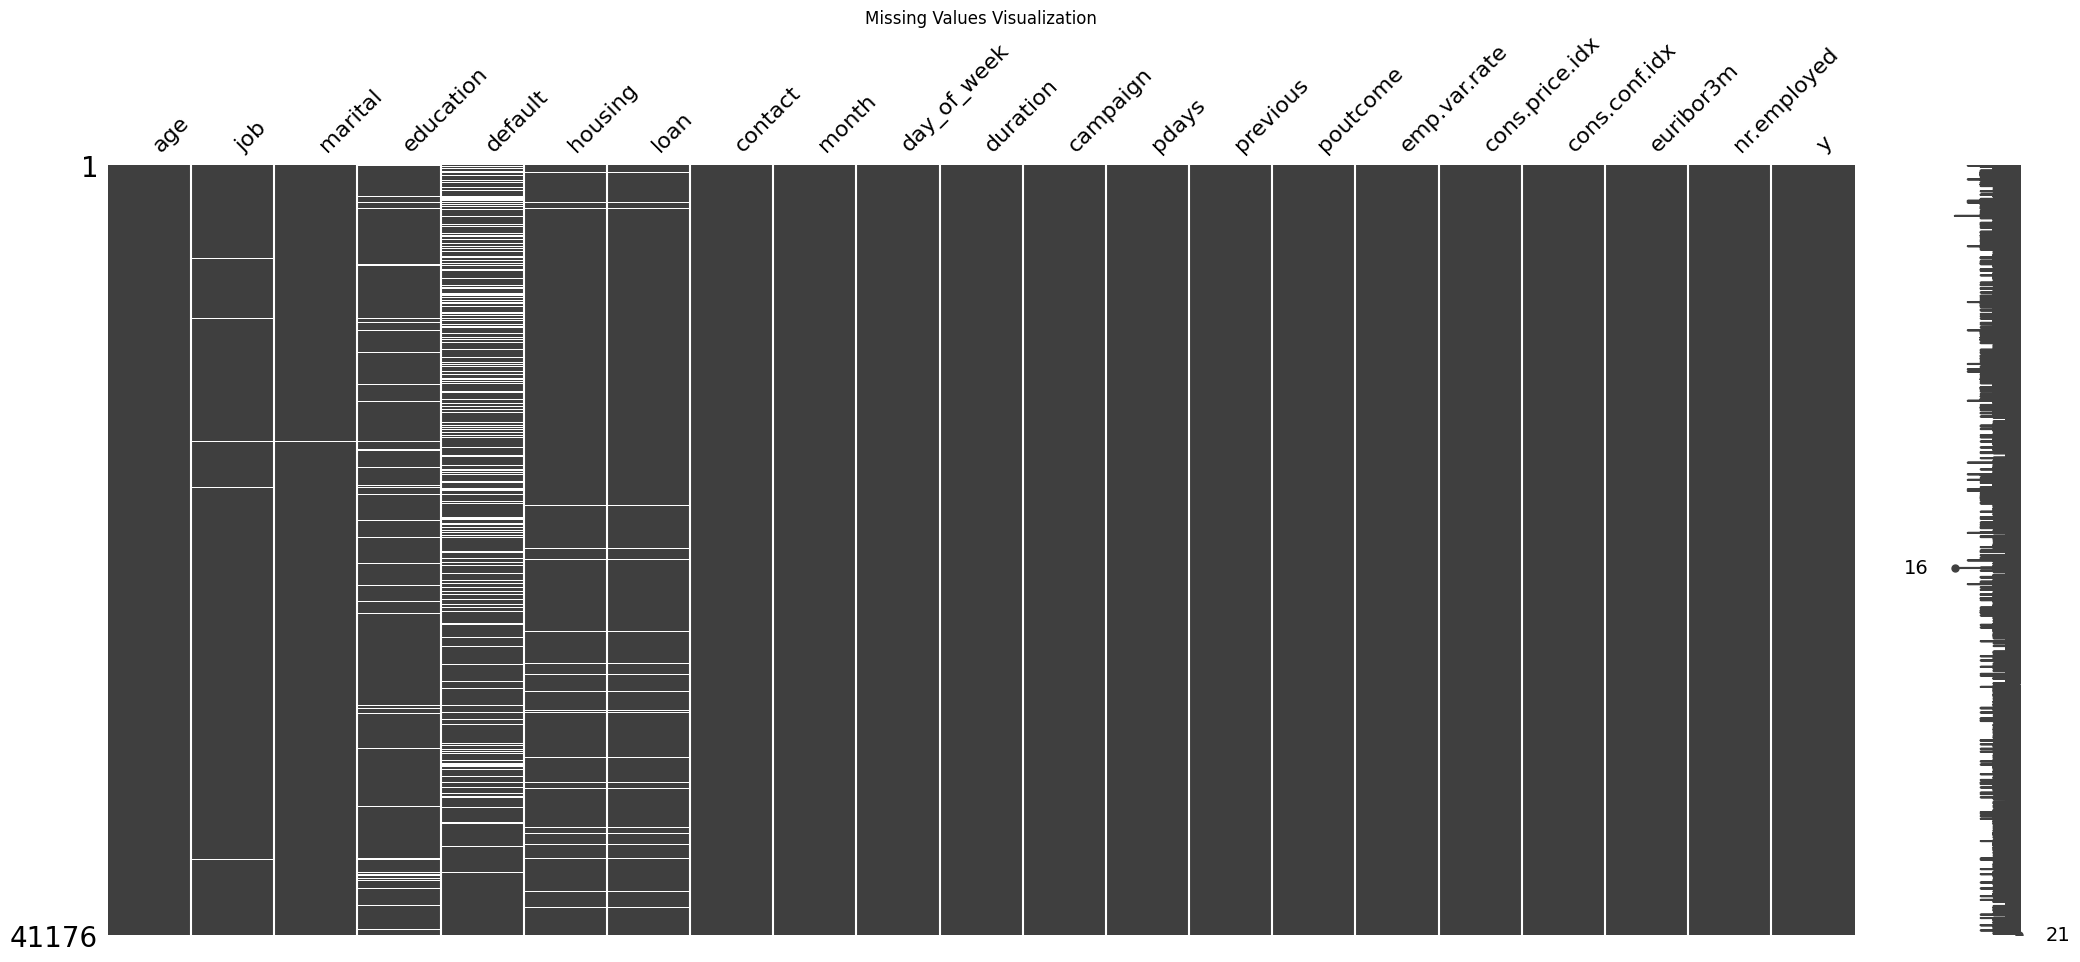

In [102]:
plt.figure(figsize=(10, 8))
msno.matrix(df)
plt.title("Missing Values Visualization")
plt.show()

In [103]:
df=df.fillna('unknown')  # 원상복구
print(df.isna().sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


## 이상치

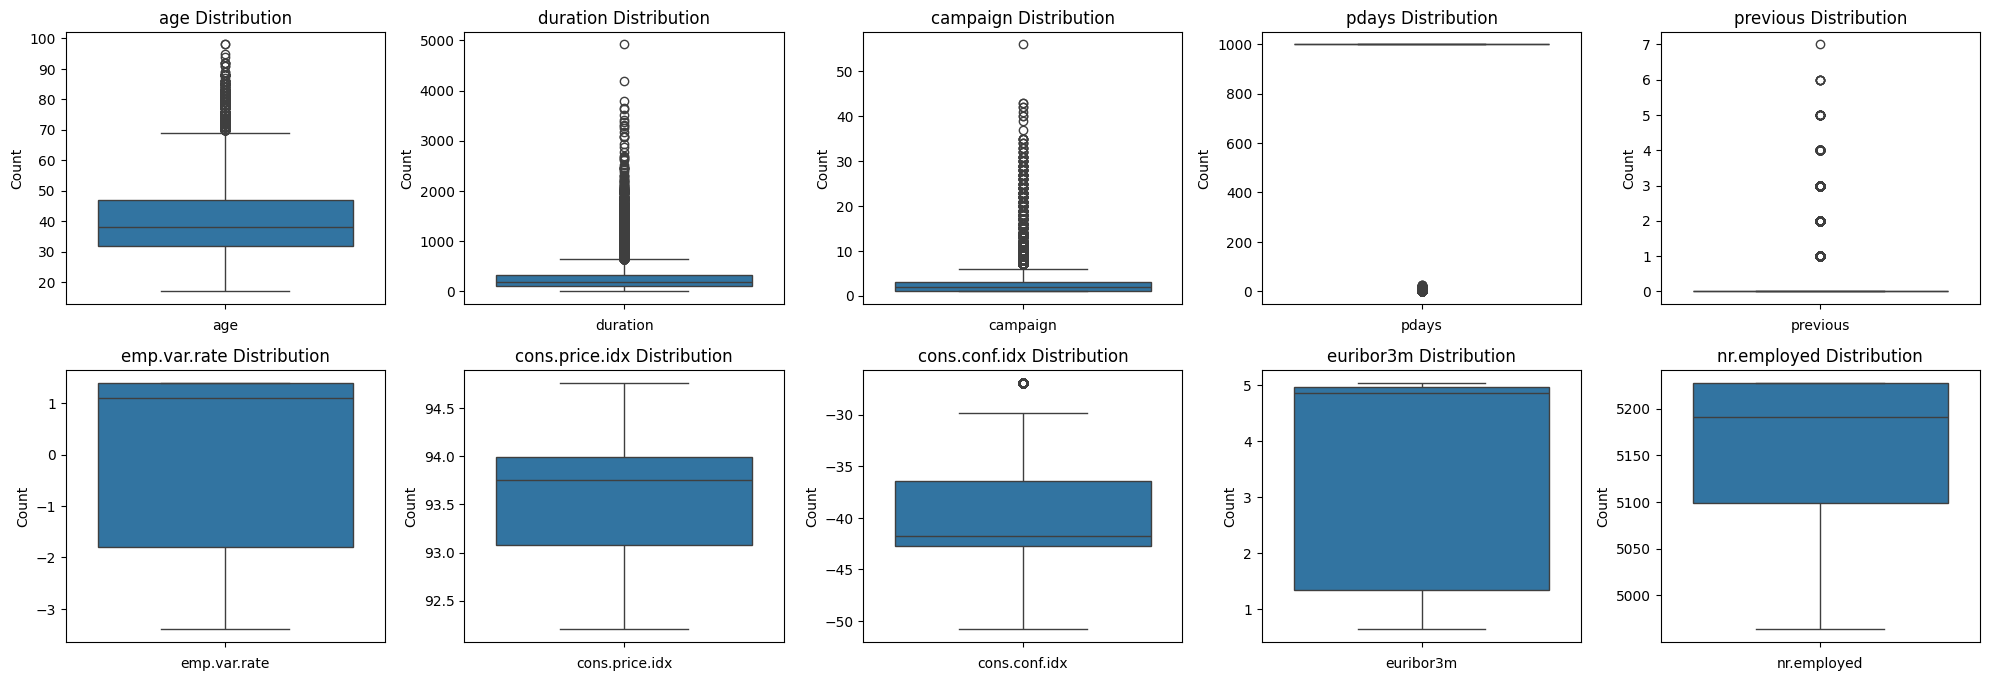

In [104]:
# 그래프 크기 설정
plt.figure(figsize=(20, 10))

# 각 열별로 시각화
for i, col in enumerate(numeric_columns, 1):
  plt.subplot(len(numeric_columns) // 5 + 1, 5, i)
  sns.boxplot(df[col])
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

## 변수별 분포 확인

### 수치형 컬럼 분포

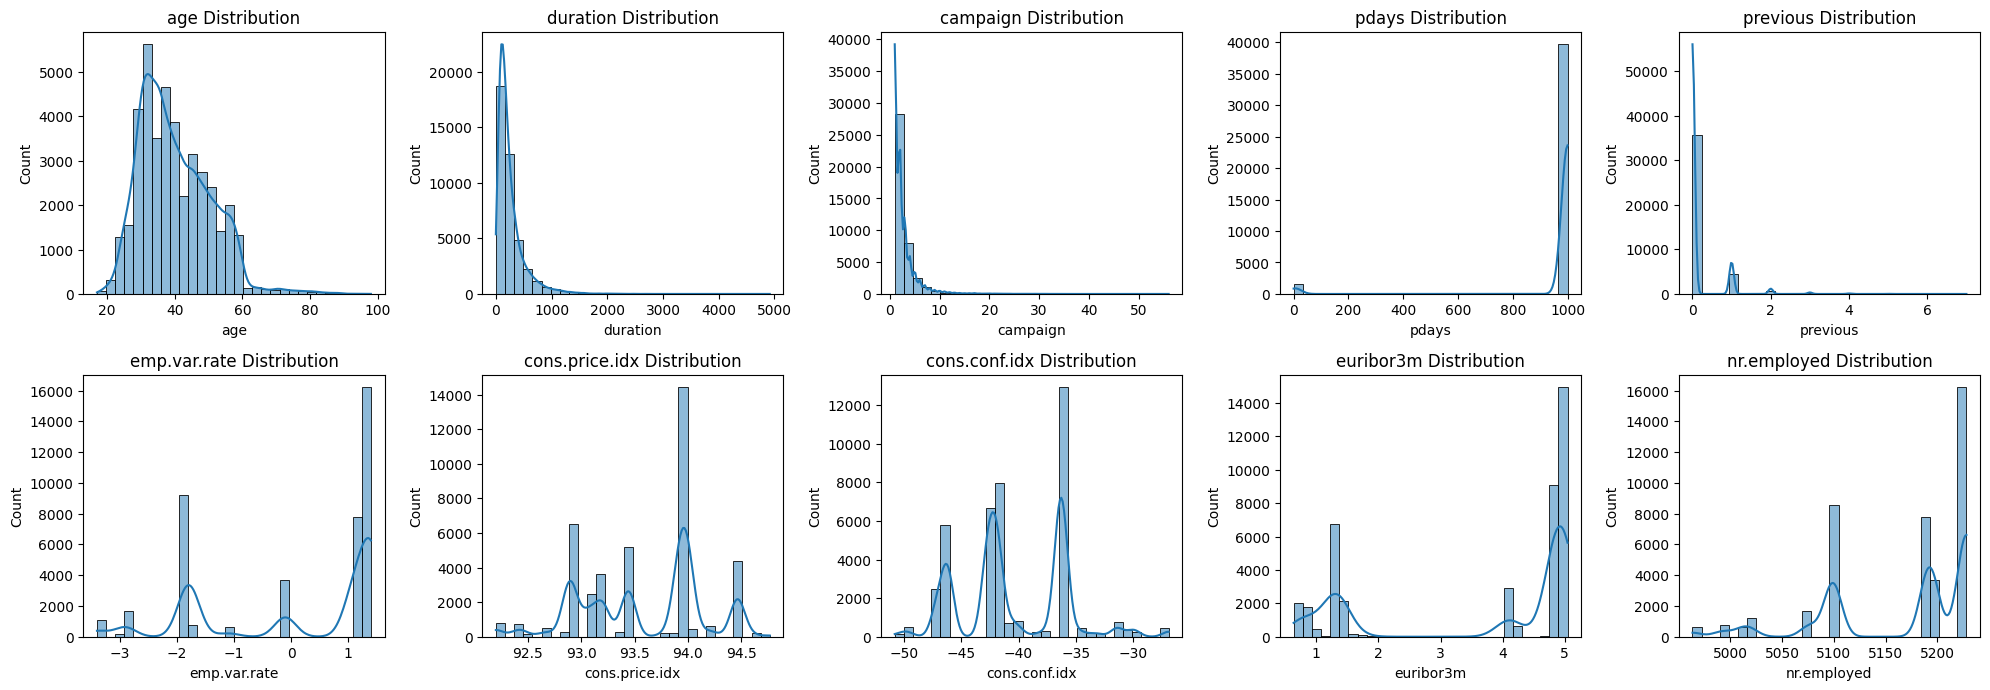

In [105]:
# 그래프 크기 설정
plt.figure(figsize=(20, 10))

for i, col in enumerate(numeric_columns, 1):
  plt.subplot(len(numeric_columns) // 5 + 1, 5, i)
  sns.histplot(df[col], bins=30, kde=True)
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

- age : 고객 나이 데이터
- duration, campaign, pdays, previous : 마케팅 캠페인 데이터
  - duration(마지막 연락 지속 시간, 초 단위 (숫자)) : 약 5000초까지 분포 (1시간 반)  
  - campaign : 현재 캠페인 접촉 성공 횟수 (숫자)
  - pday : 이전 캠페인 이후 경과 일수. **999는 이전에 연락한 적이 없음을 의미**  
    - **999 == nonexistent 여야함**
  - previous : 이번 캠페인 이전의 총 접촉 성공 횟수
  - poutcome  : 이전 캠페인의 결과: "failure" (실패), "nonexistent" (이전 접촉 없음), "success" (성공)

- 거시적 경제 상황 데이터 (아랫줄)

| 변수 | 의미 | 해석 |
|------|------|------|
| **`emp.var.rate`** | 고용 변동률 (Employment Variation Rate) | **높으면 경제 호황, 낮으면 실업률 증가** |
| **`cons.price.idx`** | 소비자 물가지수 (Consumer Price Index - CPI) | **높으면 인플레이션, 낮으면 디플레이션 위험** |
| **`cons.conf.idx`** | 소비자 신뢰지수 (Consumer Confidence Index - CCI) | **낮으면 소비 위축, 높으면 소비 증가** |
| **`euribor3m`** | 유로존 단기 금리 (Euribor 3 Month Rate) | **높으면 대출 부담 증가, 낮으면 경제 활성화** |
| **`nr.employed`** | 고용 인구 수 (Number of Employed People) | **많으면 경제 성장, 적으면 실업 증가** |

### 범주형 컬럼 분포

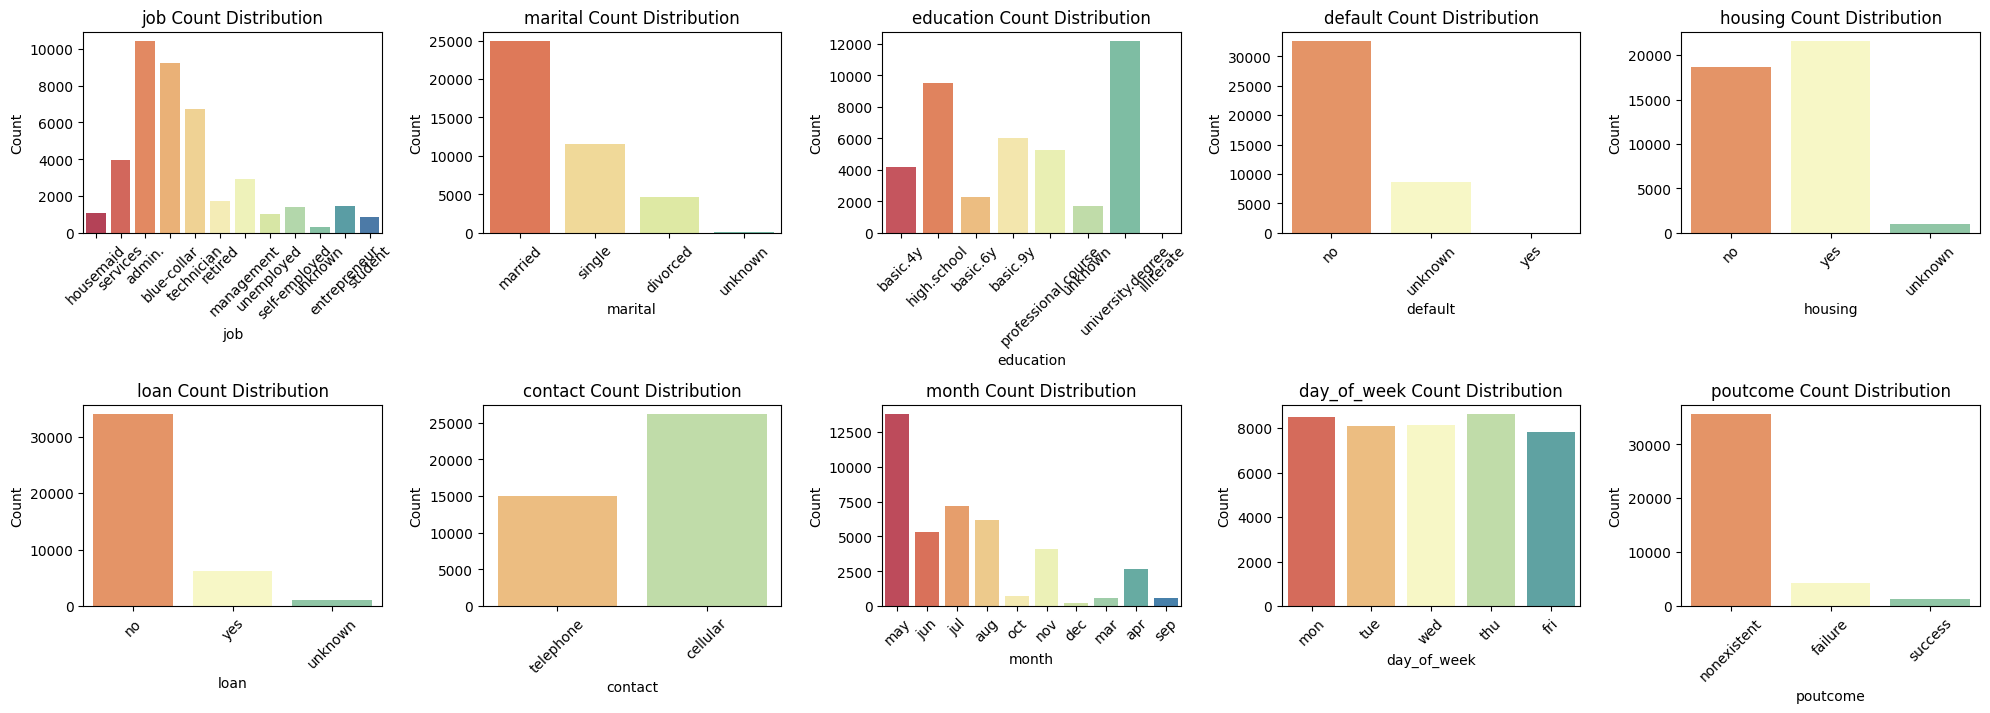

In [106]:
# 그래프 크기 설정
plt.figure(figsize=(20, 10))

for i, col in enumerate(categorical_columns, 1):
  plt.subplot(len(categorical_columns) // 5 + 1, 5, i)
  sns.countplot(x=df[col], hue=df[col], legend=False, palette='Spectral')
  plt.xticks(rotation=45)
  plt.xlabel(col)
  plt.ylabel("Count")
  plt.title(f"{col} Count Distribution")

plt.tight_layout()
plt.show()

### 타겟 변수(y) 비율 확인

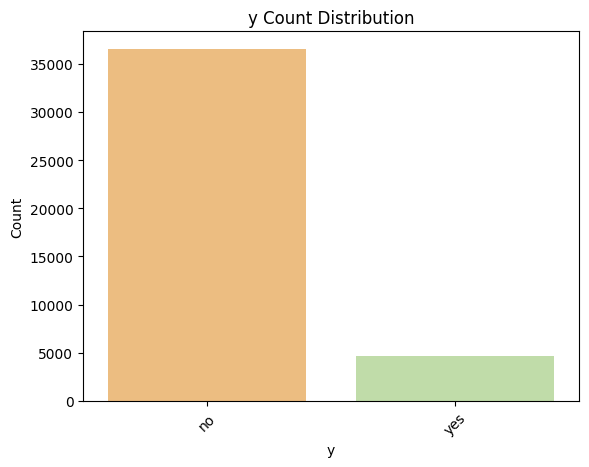

In [107]:
sns.countplot(x=df['y'], hue=df['y'], legend=False, palette='Spectral')
plt.xticks(rotation=45)
plt.xlabel('y')
plt.ylabel("Count")
plt.title(f"y Count Distribution")
plt.show()

In [108]:
df['y'].value_counts()

,count
y,
no,36537
yes,4639


## 상관관계 분석

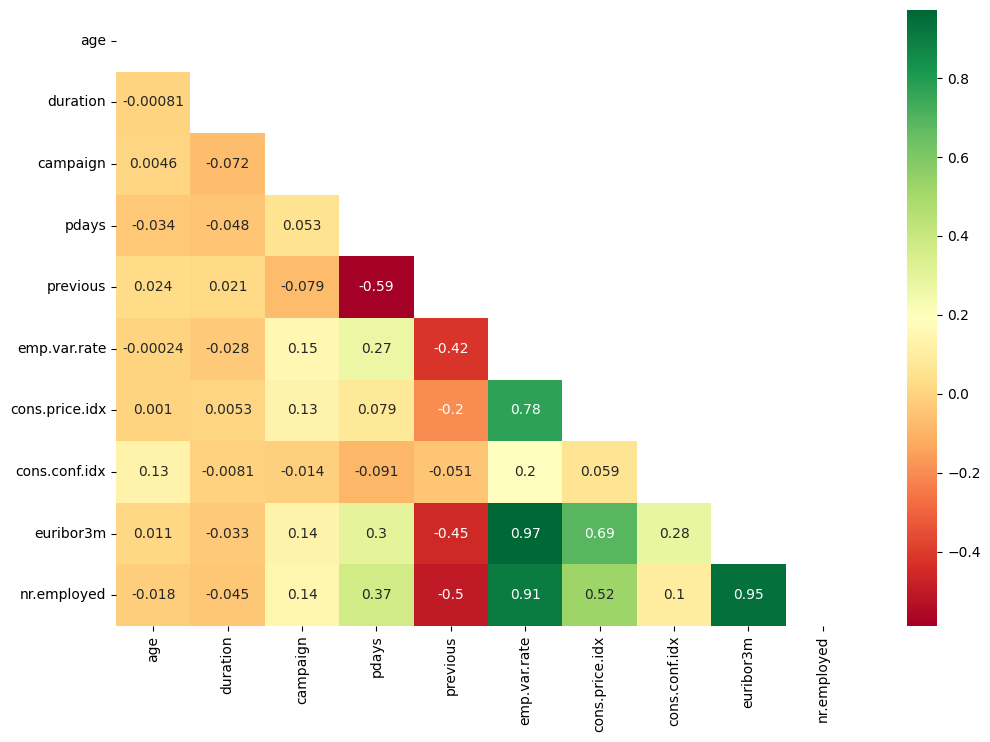

In [109]:
# 상관 행렬 계산
corr_matrix = df[numeric_columns].corr()

# 상삼각 행렬을 NaN으로 변경 (하삼각만 남김)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap="RdYlGn", mask=mask)
plt.show()

## 개인 특성 관련 변수(age, job, marital, education, default, housing, loan)와 y 관계 탐색

고객이 예금에 가입(y=1)하는 데 있어 개인 특성 관련 변수들이 어떤 영향을 미치는지 분석

- 1. 현재 캠페인에서 연락 횟수가 많을수록 가입 확률이 높아지는가?

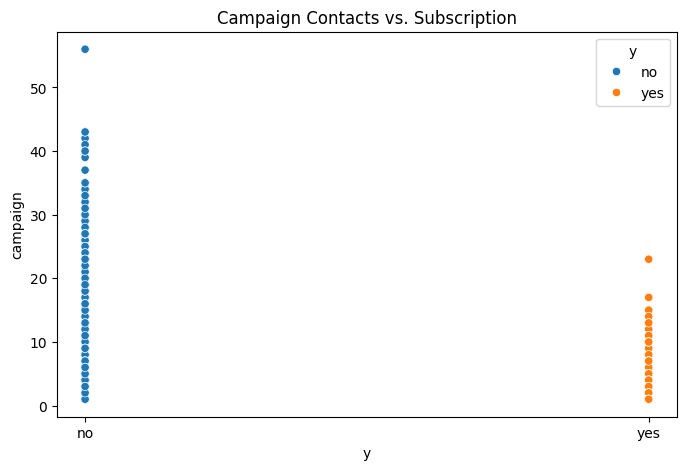

In [110]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(x=df['y'], y=df['campaign'], hue=df['y'])
plt.title("Campaign Contacts vs. Subscription")
plt.show()


- 가입한 고객(y=1)은 campaign 값이 낮은 편 → 너무 많이 연락하면 오히려 역효과일 가능성

- 가입 확률 비교

In [111]:
df['y']=df['y'].map({'yes': 1, 'no': 0})

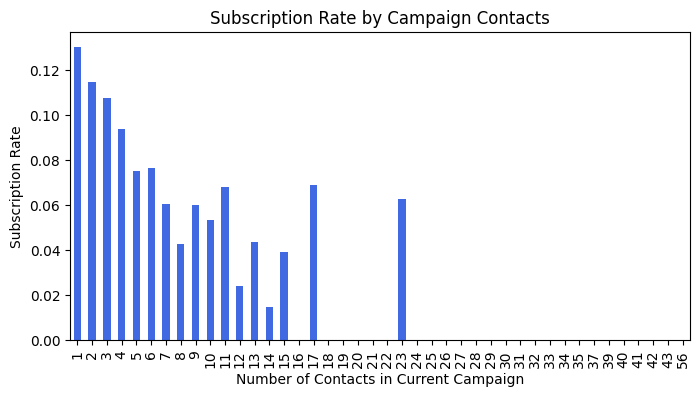

In [112]:
df.groupby('campaign')['y'].mean().plot(kind='bar', figsize=(8,4), color='royalblue')
plt.title("Subscription Rate by Campaign Contacts")
plt.xlabel("Number of Contacts in Current Campaign")
plt.ylabel("Subscription Rate")
plt.show()


- 2. 이전 캠페인에서 연락한 고객이 현재 가입할 확률이 높은가?

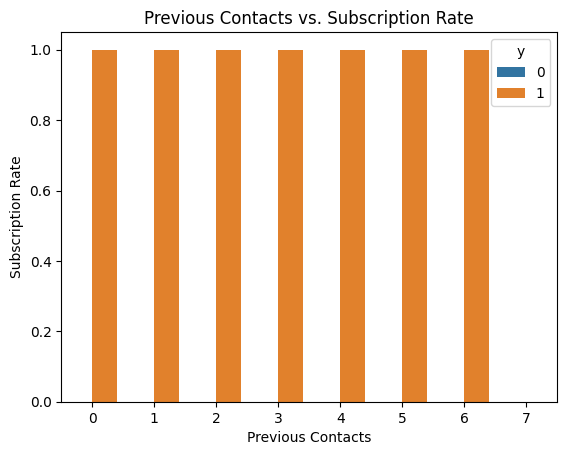

In [113]:
sns.barplot(x=df['previous'], y=df['y'], errorbar=None, hue=df['y'])
plt.title("Previous Contacts vs. Subscription Rate")
plt.xlabel("Previous Contacts")
plt.ylabel("Subscription Rate")
plt.show()


- 과거 캠페인(previous)에서 연락받았던 고객이 현재 가입할 확률이 높음!
previous=0인 고객보다, 과거에 1번 이상 연락받았던 고객이 현재 캠페인에서 예금을 가입할 확률이 높아짐

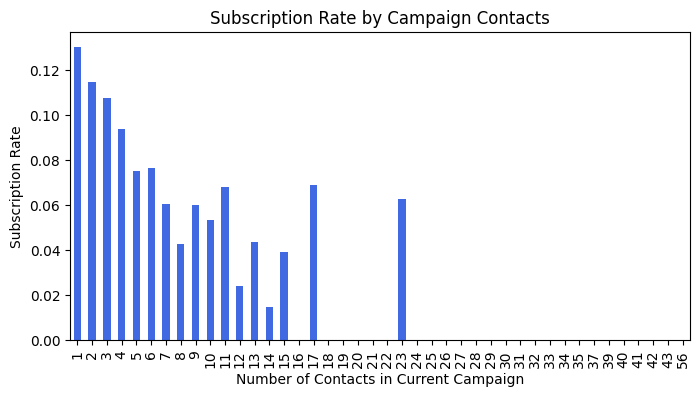

In [114]:
df.groupby('campaign')['y'].mean().plot(kind='bar', figsize=(8,4), color='royalblue')
plt.title("Subscription Rate by Campaign Contacts")
plt.xlabel("Number of Contacts in Current Campaign")
plt.ylabel("Subscription Rate")
plt.show()


- 오래전에 연락한 고객과 최근에 연락한 고객 중 누가 더 잘 가입하는가?

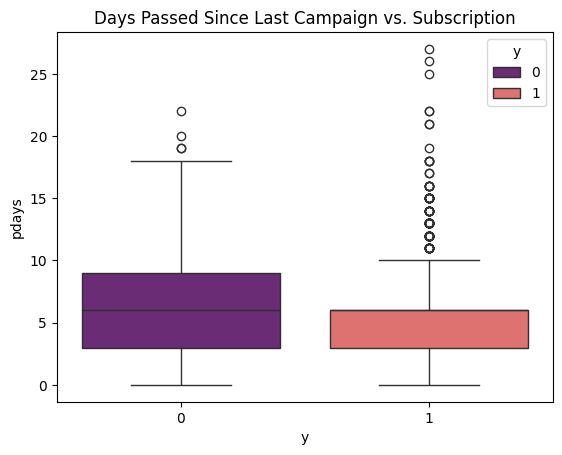

In [115]:
sns.boxplot(x=df['y'], y=df[df['pdays'] != 999]['pdays'], palette='magma', hue=df['y'])
plt.title("Days Passed Since Last Campaign vs. Subscription")
plt.show()


너무 많이 연락하면 역효과

## 마케팅 관련 변수(campaign, previous, pdays등)와 y 관계 탐색

- 고객이 예금에 가입(y=1)하는 데 있어 마케팅 캠페인 관련 변수들이 어떤 영향을 미치는지 분석

## 경제 관련 변수(emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed)와 y 관계 탐색

 # 2. 랜덤 포레스트 1차 실행 → 주요 변수 확인

In [116]:
df_1 = pd.get_dummies(df, columns=categorical_columns)

In [117]:
X = df_1.drop('y', axis=1)
y = df_1['y']

In [118]:
# 데이터 분할 (80% 학습, 20% 검증)
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 랜덤 포레스트 모델 정의 및 학습
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 검증 데이터 예측
y_pred = model.predict(X_valid)

# 성능 평가
accuracy = accuracy_score(y_valid, y_pred)
print(f"✅ 랜덤 포레스트 정확도: {accuracy:.4f}")

print("\n📌 분류 보고서 (Classification Report):")
print(classification_report(y_valid, y_pred))


✅ 랜덤 포레스트 정확도: 0.9140

📌 분류 보고서 (Classification Report):
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7308
           1       0.67      0.47      0.55       928

    accuracy                           0.91      8236
   macro avg       0.80      0.72      0.75      8236
weighted avg       0.90      0.91      0.91      8236



In [119]:
# 가장 중요한 변수 확인 (특성 중요도)
feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

print("\n📊 주요 변수 중요도:")
print(feature_importances.head(15))



📊 주요 변수 중요도:
                        Feature  Importance
1                      duration    0.278381
8                     euribor3m    0.095215
0                           age    0.081103
9                   nr.employed    0.048760
2                      campaign    0.039055
3                         pdays    0.032412
5                  emp.var.rate    0.024250
7                 cons.conf.idx    0.023497
6                cons.price.idx    0.022887
62             poutcome_success    0.015639
39                  housing_yes    0.012984
37                   housing_no    0.012882
10                   job_admin.    0.012455
32  education_university.degree    0.012033
23              marital_married    0.011686


In [136]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report

# 부스팅 모델 정의 및 학습
boost_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
boost_model.fit(X_train, y_train)

# 검증 데이터 예측
y_pred_boost = boost_model.predict(X_valid)

# 성능 평가
boost_accuracy = accuracy_score(y_valid, y_pred_boost)
print(f"✅ 그래디언트 부스팅 정확도: {boost_accuracy:.4f}")

print("\n📌 분류 보고서 (Classification Report):")
print(classification_report(y_valid, y_pred_boost))


✅ 그래디언트 부스팅 정확도: 0.9166

📌 분류 보고서 (Classification Report):
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      7308
           1       0.65      0.55      0.60       928

    accuracy                           0.92      8236
   macro avg       0.80      0.76      0.78      8236
weighted avg       0.91      0.92      0.91      8236



- support값이 낮아서 데이터 불균형 문제 있음. SMOTE를 사용해야함

In [138]:
# 랜덤 포레스트 중요 변수 확인
rf_feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
rf_feature_importances = rf_feature_importances.sort_values(by='Importance', ascending=False)

# 그래디언트 부스팅 중요 변수 확인
gb_feature_importances = pd.DataFrame({'Feature': X.columns, 'Importance': boost_model.feature_importances_})
gb_feature_importances = gb_feature_importances.sort_values(by='Importance', ascending=False)

# 랜덤 포레스트 주요 변수 출력
print("\n🌳 랜덤 포레스트 주요 변수 중요도:")
print(rf_feature_importances.head(15))

# 그래디언트 부스팅 주요 변수 출력
print("\n🔥 그래디언트 부스팅 주요 변수 중요도:")
print(gb_feature_importances.head(15))




🌳 랜덤 포레스트 주요 변수 중요도:
                        Feature  Importance
1                      duration    0.278381
8                     euribor3m    0.095215
0                           age    0.081103
9                   nr.employed    0.048760
2                      campaign    0.039055
3                         pdays    0.032412
5                  emp.var.rate    0.024250
7                 cons.conf.idx    0.023497
6                cons.price.idx    0.022887
62             poutcome_success    0.015639
39                  housing_yes    0.012984
37                   housing_no    0.012882
10                   job_admin.    0.012455
32  education_university.degree    0.012033
23              marital_married    0.011686

🔥 그래디언트 부스팅 주요 변수 중요도:
             Feature  Importance
1           duration    0.478368
9        nr.employed    0.255337
8          euribor3m    0.086110
3              pdays    0.053317
7      cons.conf.idx    0.031171
62  poutcome_success    0.018291
6     cons.price.id

### 🔍 변수 중요도 비교 및 분석

#### 🎯 공통적으로 중요한 변수
두 모델에서 모두 높은 중요도를 보이는 변수:

duration (통화 시간) → 가장 중요한 변수 ✅  
euribor3m (유리보 3개월 금리)  
nr.employed (고용자 수)  
pdays (이전 캠페인 후 경과 일수)  
cons.conf.idx (소비자 신뢰 지수)  
cons.price.idx (소비자 물가지수)  
poutcome_success (이전 캠페인의 성공 여부)  
age (나이)  
emp.var.rate (고용 변동률)


✅ 이 변수들은 랜덤 포레스트와 부스팅 모델 모두에서 중요하게 작용하므로, 모델 개선 시 주목해야 할 주요 특징들입니다.  
예를 들어, duration이 모델에서 매우 중요한 변수로 작용하는데, 이는 고객과의 통화 시간이 길수록 정기 예금 가입 확률이 높다는 의미

### 🚀 모델별 차이점
#### 랜덤 포레스트 (🌳)

campaign (현재 캠페인 동안 연락 횟수)가 5번째로 중요한 변수  
housing_yes & housing_no (주택대출 여부)가 중요한 변수로 포함됨  
education_university.degree (대학 학위 여부), marital_married (결혼 여부) 등이 중요 변수에 포함됨  

#### 그래디언트 부스팅 (🔥)

month_mar, month_oct, month_apr (마지막 통화 월)이 중요하게 작용  
contact_cellular (연락 방식: 휴대폰) 변수가 포함됨  
poutcome_failure (이전 캠페인 실패 여부)도 일부 영향 있음  
campaign 변수의 중요도가 매우 낮아짐  

✅ 즉, 랜덤 포레스트는 개별적인 행동 및 인구통계적 특징을 강조하는 반면, 그래디언트 부스팅은 더 시계열적 요소 (연락 월 등)에 집중하는 경향이 있다

## 🛠 모델 개선

1. `duration` 변수를 제외한 이유 검토
- duration 변수는 통화 시간이 끝난 후 결정되는 변수

즉, 마케팅 활동이 이미 이루어진 후에 측정됨.
사전 예측용 변수로 활용하기 어려움  
→ 예측 모델을 만들어도 실제 캠페인 전에 사용할 수 없음.
- 통화 시간이 길수록 정기 예금 가입 확률이 높을 가능성이 큼

이는 상식적으로도 맞는 이야기지만, 마케팅 전략을 수립하기 전에는 사용할 수 없는 정보  
예측 모델을 통해 캠페인 타겟을 미리 설정하려면 duration 없이 모델을 구축하는 것이 현실적인 접근 방식  
- 해결책: duration을 활용하는 대신, "예측 가능 변수"에 집중

고객 특성(예: 나이, 대출 여부, 교육 수준)과 경제적 요인(예: 금리, 고용률) 등을 활용하여 고객이 가입할 가능성이 높은 대상을 미리 예측하는 것이 목표  
campaign(연락 횟수), contact_cellular(연락 방식), day_of_week(통화 요일) 같은 변수들이 duration을 대체할 수 있는가? → 이를 중심으로 분석 진행  

In [143]:
# duration 변수 제거
X_new = X.drop(columns=['duration'])
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# SMOTE 적용을 위한 데이터 준비
smote = SMOTE(random_state=42)

# SMOTE를 사용하여 데이터 오버샘플링 수행
X_resampled, y_resampled = smote.fit_resample(X_new, y)  # duration 제거한 데이터 사용

# 데이터 분할 (80% 학습, 20% 검증)
X_train_smote, X_valid_smote, y_train_smote, y_valid_smote = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled
)

print(f"✅ SMOTE 적용 후 학습 데이터 크기: {X_train_smote.shape}, 검증 데이터 크기: {X_valid_smote.shape}")

✅ SMOTE 적용 후 학습 데이터 크기: (58459, 62), 검증 데이터 크기: (14615, 62)


In [144]:
# 랜덤 포레스트 모델 학습
model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
model_smote.fit(X_train_smote, y_train_smote)

# 검증 데이터 예측
y_pred_smote = model_smote.predict(X_valid_smote)

# 성능 평가
accuracy_smote = accuracy_score(y_valid_smote, y_pred_smote)
print(f"✅ (SMOTE 적용) 랜덤 포레스트 정확도: {accuracy_smote:.4f}")

print("\n📌 분류 보고서 (Classification Report):")
print(classification_report(y_valid_smote, y_pred_smote))

✅ (SMOTE 적용) 랜덤 포레스트 정확도: 0.9458

📌 분류 보고서 (Classification Report):
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      7308
           1       0.95      0.94      0.95      7307

    accuracy                           0.95     14615
   macro avg       0.95      0.95      0.95     14615
weighted avg       0.95      0.95      0.95     14615



In [145]:
# 부스팅 모델 학습
boost_model_smote = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
boost_model_smote.fit(X_train_smote, y_train_smote)

# 검증 데이터 예측
y_pred_boost_smote = boost_model_smote.predict(X_valid_smote)

# 성능 평가
boost_accuracy_smote = accuracy_score(y_valid_smote, y_pred_boost_smote)
print(f"✅ (SMOTE 적용) 그래디언트 부스팅 정확도: {boost_accuracy_smote:.4f}")

print("\n📌 분류 보고서 (Classification Report):")
print(classification_report(y_valid_smote, y_pred_boost_smote))


✅ (SMOTE 적용) 그래디언트 부스팅 정확도: 0.9141

📌 분류 보고서 (Classification Report):
              precision    recall  f1-score   support

           0       0.89      0.94      0.92      7308
           1       0.94      0.89      0.91      7307

    accuracy                           0.91     14615
   macro avg       0.92      0.91      0.91     14615
weighted avg       0.92      0.91      0.91     14615



In [146]:
# 랜덤 포레스트 중요 변수 확인
rf_feature_importances_smote = pd.DataFrame({'Feature': X_new.columns, 'Importance': model_smote.feature_importances_})
rf_feature_importances_smote = rf_feature_importances_smote.sort_values(by='Importance', ascending=False)

# 그래디언트 부스팅 중요 변수 확인
gb_feature_importances_smote = pd.DataFrame({'Feature': X_new.columns, 'Importance': boost_model_smote.feature_importances_})
gb_feature_importances_smote = gb_feature_importances_smote.sort_values(by='Importance', ascending=False)

# 결과 출력
print("\n🌳 (SMOTE 적용) 랜덤 포레스트 주요 변수 중요도:")
print(rf_feature_importances_smote.head(15))

print("\n🔥 (SMOTE 적용) 그래디언트 부스팅 주요 변수 중요도:")
print(gb_feature_importances_smote.head(15))



🌳 (SMOTE 적용) 랜덤 포레스트 주요 변수 중요도:
                        Feature  Importance
7                     euribor3m    0.113435
0                           age    0.072349
8                   nr.employed    0.060810
4                  emp.var.rate    0.049652
1                      campaign    0.037766
6                 cons.conf.idx    0.029885
42             contact_cellular    0.027850
5                cons.price.idx    0.026034
38                  housing_yes    0.025917
36                   housing_no    0.024931
31  education_university.degree    0.023302
57              day_of_week_tue    0.022148
56              day_of_week_thu    0.021781
58              day_of_week_wed    0.021050
55              day_of_week_mon    0.021042

🔥 (SMOTE 적용) 그래디언트 부스팅 주요 변수 중요도:
                        Feature  Importance
8                   nr.employed    0.331714
6                 cons.conf.idx    0.047266
38                  housing_yes    0.046209
58              day_of_week_wed    0.038709
41      

## 🔍 **2. 최종 변수 중요도 분석**
**SMOTE 적용 후 모델이 중요하게 평가한 변수들을 바탕으로, 고객의 가입 여부를 예측하는 마케팅 전략을 세울 수 있습니다.**

---

### 🎯 **(A) 거시 경제 변수 (Macro-Economic Factors)**
📌 **이 변수들은 "경제 환경"이 예금 가입 결정에 미치는 영향을 반영합니다.**

| 변수 | 설명 | 랜덤 포레스트 중요도 | 부스팅 중요도 | 분석 |
|------|------|-----------------|-----------------|------|
| `nr.employed` | 고용자 수 (고용률) | 0.060 | **0.332** 🚀 | ✅ 고용률이 높은 시기에 예금 가입률이 증가할 가능성 높음 |
| `euribor3m` | 3개월 유리보 금리 | **0.113** 🚀 | 0.029 | ✅ 금리가 높아지면 예금 가입 확률 증가 가능 |
| `emp.var.rate` | 고용 변동률 | 0.049 | - | ✅ 경기 침체 시 예금 가입 가능성이 변할 수 있음 |
| `cons.conf.idx` | 소비자 신뢰지수 | 0.030 | **0.047** 🚀 | ✅ 소비자 신뢰도가 낮아지면 안정적인 예금 상품 선호 가능 |

**🔹 인사이트**
- **고용률(nr.employed)이 가장 중요한 변수** → 실업률이 낮고 고용률이 높을수록 예금 가입 가능성이 큼.
- **금리(euribor3m)가 높은 시기에는 예금 가입이 늘어날 가능성** → 금리 변동 추이를 분석해 최적의 마케팅 시점 설정 가능.

---

### 🎯 **(B) 고객 특성 (Customer Profile)**
📌 **고객의 개인 특성이 예금 가입 가능성에 미치는 영향을 평가**

| 변수 | 설명 | 랜덤 포레스트 중요도 | 부스팅 중요도 | 분석 |
|------|------|-----------------|-----------------|------|
| `age` | 나이 | 0.072 | 0.021 | ✅ 연령대별 가입 패턴 분석 필요 |
| `housing_yes` | 주택 대출 있음 | 0.026 | **0.046** 🚀 | ✅ 주택 대출 여부가 예금 가입 결정에 영향 |
| `loan_yes` | 개인 대출 있음 | - | **0.036** 🚀 | ✅ 추가 대출이 있는 고객일수록 예금 가입 가능성이 낮을 수 있음 |
| `education_university.degree` | 대학교 학위 여부 | 0.023 | 0.025 | ✅ 고학력층에서 예금 가입 비율이 높을 가능성 |

**🔹 인사이트**
- 주택 대출(`housing_yes`)이 있는 고객은 예금 가입 확률이 상대적으로 높음.
- 개인 대출(`loan_yes`)이 있는 고객은 예금 가입 가능성이 낮을 수 있음 → 금융 부담이 클 가능성.
- **연령대별로 예금 가입률이 다를 가능성이 크므로, 고객 세분화(Segmentation) 분석 필요**.

---

### 🎯 **(C) 마케팅 전략 관련 변수**
📌 **마케팅 활동이 예금 가입에 미치는 영향을 분석**

| 변수 | 설명 | 랜덤 포레스트 중요도 | 부스팅 중요도 | 분석 |
|------|------|-----------------|-----------------|------|
| `campaign` | 고객에게 연락한 횟수 | 0.038 | 0.009 | ✅ 연락 횟수가 많을수록 가입 확률 증가 가능 |
| `contact_cellular` | 연락 방식 (휴대폰) | 0.028 | **0.031** 🚀 | ✅ 휴대폰 연락이 예금 가입에 효과적 |
| `day_of_week_*` | 마지막 통화 요일 | 0.021~0.022 | 0.026~0.038 | ✅ 특정 요일에 고객 응답률이 높을 가능성 |

**🔹 인사이트**
- **campaign(연락 횟수)**: 적정 횟수 이상 연락하면 가입 확률이 증가할 가능성.
- **contact_cellular(휴대폰 연락이 더 효과적)** → 이메일보다 전화 캠페인이 효과적일 수 있음.
- **특정 요일(day_of_week)이 가입률에 영향** → 가장 효과적인 요일에 집중 마케팅 진행.

---

## 🎯 **3. 최종 마케팅 전략**
### 🚀 **(A) 경제적 요인을 고려한 캠페인 전략**
- `nr.employed` (**고용률**) & `euribor3m` (**금리**) → **고용률이 높고 금리가 높은 시기에 예금 마케팅 강화**  
- `cons.conf.idx` (**소비자 신뢰지수**) → 신뢰도가 낮은 시기에는 **안정적인 예금 상품을 강조하는 전략 필요**  

---

### 🎯 **(B) 고객 세분화 및 타겟팅 전략**
- **고학력층(`education_university.degree`) & 주택 대출 보유 고객(`housing_yes`)이 타겟이 될 가능성이 높음**  
- **개인 대출(`loan_yes`) 보유 고객은 예금 가입 가능성이 낮으므로 우선순위에서 제외 가능**  

---

### 📢 **(C) 마케팅 실행 최적화**
- **`campaign` (연락 횟수)는 적정 횟수를 유지하며, 타겟 고객을 선별적으로 공략**  
- **`contact_cellular` (휴대폰 연락)를 중심으로 마케팅 캠페인 진행**  
- **가장 효과적인 요일(`day_of_week`)을 분석하여 집중 마케팅 진행**  

---

📌 **이제 연령별·직업별·마케팅 방식별 세부 분석을 진행하면 더욱 정교한 전략을 수립할 수 있음!** 🚀


# 3. 피처 엔지니어링 (랜덤 포레스트 결과 기반 추가 변수 생성)

## 경제지표를 이용한 클러스터링 (시기 추정)

In [120]:
from sklearn.cluster import KMeans
# 클러스터링을 위한 변수 선택
year_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# K-Means 클러스터링 적용 (3개 그룹으로 가정, 2008~2010년 3년치일 가능성이 높음)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['year_cluster'] = kmeans.fit_predict(df[year_features])

year_cluster_counts = df['year_cluster'].value_counts()
year_cluster_counts

,count
year_cluster,
1,27682
0,10194
2,3300


In [121]:
# 1. 클러스터별 평균 pdays 계산 (999가 아닌 값만 사용)
year_cluster_pdays_mean = df[df['pdays'] != 999].groupby('year_cluster')['pdays'].mean()

# 각 클러스터별 예금 가입 여부(y)의 분포 확인
year_cluster_y_counts = df.groupby('year_cluster')['y'].value_counts(normalize=True).unstack() * 100
year_cluster_y_counts

y,0,1
year_cluster,,
0,83.470669,16.529331
1,95.162922,4.837078
2,51.060606,48.939394


✔ year_cluster 0 → 중간 수준 (16.53% 가입)  
✔ year_cluster 1 → 예금 가입률이 가장 낮음 (4.84% 가입)  
✔ year_cluster 2 → 예금 가입률이 가장 높음 (48.92% 가입)  

In [122]:
# 클러스터별 경제 지표 비교
economic_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# 클러스터별 평균 경제 지표 계산
year_cluster_econ_means = df.groupby('year_cluster')[economic_features].mean()
year_cluster_econ_means

,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
year_cluster,,,,,
0,-1.979341,92.880761,-44.806602,1.292344,5095.366451
1,1.115786,93.842690,-39.462098,4.817123,5213.382248
2,-2.223212,93.483039,-35.938667,0.784435,4999.640848


1. 클러스터 0 (year_cluster == 0)
고용 감소(emp.var.rate = -1.98), 낮은 소비자 신뢰(-44.81), 낮은 금리(euribor3m = 1.29)
경제 불황 가능성 높음 → 사람들이 예금 가입을 선호할 가능성이 있음 (2009년 예상)

2. 클러스터 1 (year_cluster == 1)
고용 증가(emp.var.rate = 1.12), 상대적 고물가(93.84), 높은 금리(euribor3m = 4.82)
경기 회복 또는 호황기 가능성 → 예금보다는 소비 증가할 가능성(2008년 예상)  

3. 클러스터 2 (year_cluster == 2)
고용 급감(-2.22), 초저금리(euribor3m = 0.78), 소비자 신뢰 상대적 상승(-35.94)
극심한 경기 불황 후 금리 인하 정책 가능성 → 예금 가입률 증가 예상 가능(2010년 예상)

주요 인사이트 1. 경제 상황에 따라 정기 예금 가입률이 크게 달라진다.

## 경제 지표(euribor3m, emp.var.rate 등) 결합 → economic_score 생성

## 연락 받은 적이 없다면서(pdays == 999) 이전 캠페인 결과(poutcome)가 nonexistent(이전 캠페인에서 한 번도 연락받은 적 없음)가 아닌 경우가 있음

In [123]:
df = pd.read_csv('bank-additional-full.csv', sep=';')

In [124]:
# pdays == 999인데 poutcome이 nonexistent가 아닌 경우
inconsistent_poutcome = df[(df['pdays'] == 999) & (df['poutcome'] != "nonexistent")]
inconsistent_poutcome

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
24013,38,blue-collar,single,unknown,no,yes,no,telephone,oct,tue,...,1,999,1,failure,-0.1,93.798,-40.4,4.968,5195.8,no
24019,40,services,married,high.school,no,yes,no,telephone,oct,tue,...,1,999,1,failure,-0.1,93.798,-40.4,4.968,5195.8,yes
24076,36,admin.,married,university.degree,no,yes,no,telephone,nov,wed,...,1,999,1,failure,-0.1,93.200,-42.0,4.663,5195.8,no
24102,36,admin.,married,high.school,no,yes,no,telephone,nov,wed,...,1,999,1,failure,-0.1,93.200,-42.0,4.286,5195.8,yes
24113,29,self-employed,married,university.degree,no,yes,no,telephone,nov,thu,...,1,999,1,failure,-0.1,93.200,-42.0,4.245,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41166,32,admin.,married,university.degree,no,no,no,telephone,nov,wed,...,1,999,1,failure,-1.1,94.767,-50.8,1.030,4963.6,yes
41170,40,management,divorced,university.degree,no,yes,no,cellular,nov,wed,...,2,999,4,failure,-1.1,94.767,-50.8,1.030,4963.6,no
41173,62,retired,married,university.degree,no,yes,no,cellular,nov,thu,...,1,999,2,failure,-1.1,94.767,-50.8,1.031,4963.6,yes
41175,34,student,single,unknown,no,yes,no,cellular,nov,thu,...,1,999,2,failure,-1.1,94.767,-50.8,1.031,4963.6,no


연락안함(pdays == 999)인데 과거 캠페인에서 실패했다는 모순 발생  
데이터 일관성이 깨져 있음  
약 4110개(10%)나 있음!!!

In [125]:
inconsistent_poutcome['previous'].value_counts()  # 이전 캠페인 접촉 횟수

,count
previous,
1,3696
2,349
3,50
4,12
5,2
6,1


전 캠페인에서 연락을 취했음
→ previous(과거 캠페인 접촉 횟수)도 1 이상이므로 이전 캠페인에서 실제로 연락받은 고객이 맞음

In [126]:
inconsistent_poutcome['poutcome'].value_counts()   # 이전 캠페인 결과

,count
poutcome,
failure,4110


과거 캠페인에서는 다 실패함

In [127]:
inconsistent_poutcome['campaign'].value_counts()   # 이전 캠페인 결과

,count
campaign,
1,2054
2,1137
3,412
4,219
5,113
6,87
7,39
8,26
9,10


현재 캠페인에서 연락을 많이 취함


> 어떻게 처리할것인가?



In [128]:
df[(df["pdays"] == 999) & (df['duration'] > 0)]['duration']

,duration
0,261
1,149
2,226
3,151
4,307
...,...
41183,334
41184,383
41185,189
41186,442


연락 받은 적이 없다면(999) 실제 통화한 총 길이(duration)도 0이여야함.  
하지만 39,669의 데이터가 통화한 길이에대한 데이터가 있음

- duration(통화길이)은 직전 캠페인이 아닌 과거 캠페인까지 포함한 데이터 일 것

In [129]:
# 조합별 개수 확인
grouped_counts = df.groupby(['pdays', 'previous', 'poutcome']).size().reset_index(name='count')
grouped_counts

,pdays,previous,poutcome,count
0,0,1,success,7
1,0,2,success,4
2,0,3,success,2
3,0,4,success,1
4,0,5,success,1
...,...,...,...,...
115,999,2,failure,349
116,999,3,failure,50
117,999,4,failure,12
118,999,5,failure,2


In [130]:
# `poutcome`만 원-핫 인코딩 수행
df = pd.get_dummies(df, columns=['poutcome'], drop_first=True)

# 인코딩된 컬럼 확인
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
       'euribor3m', 'nr.employed', 'y', 'poutcome_nonexistent',
       'poutcome_success'],
      dtype='object')


In [132]:
# 'y' 열을 숫자로 변환 (yes → 1, no → 0)
df["y"] = df["y"].map({"yes": 1, "no": 0})

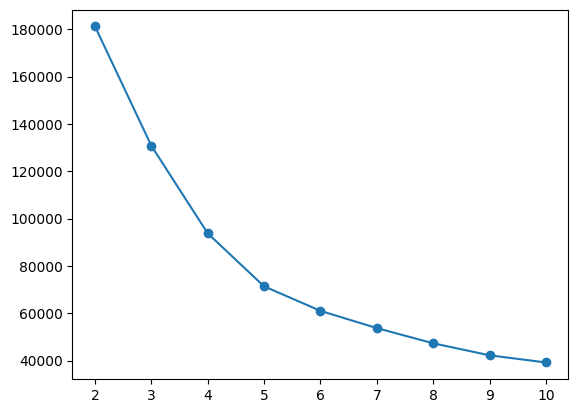

In [133]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd

# 클러스터링을 위한 변수 선정
features = ["previous", "pdays", "campaign", "duration","poutcome_nonexistent","poutcome_success","y"]
df_cluster = df[features].copy()

# 데이터 정규화
scaler = StandardScaler()
df_cluster_scaled = scaler.fit_transform(df_cluster)

# 최적 클러스터 개수 찾기
wcss = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_cluster_scaled)
    wcss.append(kmeans.inertia_)

# Elbow Method 시각화
plt.plot(K_range, wcss, marker='o')

plt.show()

# 최적 클러스터 개수 결정 후 K-means 실행
optimal_k = 5  # 4로 가정, 실제 실행 후 결정
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(df_cluster_scaled)



In [134]:
# 클러스터별 평균값 확인
df.groupby("cluster")[features].mean()

,previous,pdays,campaign,duration,poutcome_nonexistent,poutcome_success,y
cluster,,,,,,,
0,0.000000,999.000000,2.094689,214.497061,1.000000,0.000000,0.000000
1,0.025220,999.000000,2.157552,702.040238,0.975347,0.000000,0.912156
2,1.651997,5.896412,1.804333,325.528775,0.000000,0.929587,0.654705
3,1.131657,989.739892,1.997288,226.509862,0.000000,0.000000,0.110207
4,0.002287,999.000000,11.280421,155.155993,0.997713,0.000000,0.003202


In [135]:
# 클러스터별 평균값 확인
df.groupby("cluster")[features].median()

,previous,pdays,campaign,duration,poutcome_nonexistent,poutcome_success,y
cluster,,,,,,,
0,0.0,999.0,2.0,166.0,1.0,0.0,0.0
1,0.0,999.0,2.0,614.0,1.0,0.0,1.0
2,1.0,6.0,1.0,256.0,0.0,1.0,1.0
3,1.0,999.0,2.0,173.0,0.0,0.0,0.0
4,0.0,999.0,9.0,95.5,1.0,0.0,0.0


In [ ]:


# 클러스터별 가입률 계산
cluster_subscription_rate = df.groupby("cluster")["y"].mean() * 100

# 클러스터별 특징 분석
cluster_features = df.groupby("cluster").agg({
    "previous": "mean",
    "pdays": "mean",
    "campaign": "mean",
    "duration": "mean",
    "poutcome_success": "mean",
    "poutcome_nonexistent": "mean"
}).reset_index()

# 클러스터별 가입률 시각화
plt.figure(figsize=(8, 5))
plt.bar(cluster_subscription_rate.index, cluster_subscription_rate.values, color="skyblue")
plt.xlabel("Cluster")
plt.ylabel("Subscription Rate (%)")
plt.title("Cluster-wise Subscription Rate (y=1)")
plt.xticks(cluster_subscription_rate.index)
plt.show()

In [ ]:
# poutcome_success가 1인 고객들의 y 값 검증
success_customers = df[df["poutcome_success"] == 1]

# 가입한 고객(y=1)과 미가입 고객(y=0) 개수 확인
success_y_counts = success_customers["y"].value_counts()

# 비율 계산
success_y_ratio = success_customers["y"].mean() * 100

# 결과 출력
success_y_counts, success_y_ratio


- 과거 마케팅 캠페인을 통해 한 번이라도 가입한 경험이 있는 고객군
- 이번 캠페인에서도 반드시 가입하는 것은 아니며, 65.1%가 다시 가입했고, 34.9%는 가입하지 않음

In [ ]:
grouped_counts.groupby('A').size()

In [ ]:
# pdays=999 이면서 previous > 0 인 데이터 개수 확인
df_filtered = df[(df["pdays"] == 999) & (df["previous"] > 0)]
print(f"pdays=999 이면서 previous>0 인 데이터 개수: {df_filtered.shape[0]}")
df_filtered


In [ ]:
df[df["pdays"] == 999].describe()  # 999인 데이터의 특징 분석

In [ ]:
df['pdays'].shape

pday는 직전 캠페인에서 연락을했냐 안했냐고
듀레이션은 전화길이인데

→ 아마도 pdays 값이 잘못 기록되어 업데이트되지 않았을 가능성이 높음
예측하여 채우는걸로 진행

In [ ]:
# 999가 아닌 pdays의 중앙값
median_pdays = df[df['pdays'] != 999]['pdays'].median()

# pdays == 999인 경우 중앙값으로 대체
df.loc[df['pdays'] == 999, 'pdays'] = median_pdays

print(f"pdays 중앙값으로 대체 완료! (대체된 값: {median_pdays})")


In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['pdays'] < 999], x="contact", y="pdays")
plt.xlabel("Contact Type")
plt.ylabel("pdays (Days Since Last Contact)")
plt.title("pdays Distribution by Contact Type")
plt.show()

# 4. 랜덤 포레스트 2차 실행 → 피처 엔지니어링 효과 확인

새 변수 포함한 데이터로 다시 랜덤 포레스트 학습
성능 비교 (정확도, Recall, Feature Importance 변화 확인)
주요 변수 중요도가 변하는지 체크

# 5. 최종 인사이트 도출 (마케팅 전략 수립)

✅ 어떤 변수가 고객의 가입 여부를 결정하는가?  
✅ 마케팅 캠페인은 어떻게 개선해야 하는가? (연락 횟수 최적화, 특정 고객 타겟팅 등)  
✅ 경제 상황이 마케팅 전략에 어떤 영향을 미치는가?  